# **Hotel Booking Demand Analysis with Machine Learning**
#### By: Darrell Lokadeva Lim

## 1. Latar Belakang 
Industri perhotelan beroperasi dengan margin yang tipis dan persediaan kurang jelas, di mana satu malam kamar yang tidak terjual hari ini tidak dapat disimpan dan dijual besoknya, pendapatannya hilang selamanya. Karena itu, mengelola permintaan secara akurat (revenue management) menjadi inti profitailitas sebuah hotel.

Akhir-akhir ini, pertumbuhan Online Travel Agency (OTA) seperti Booking.com, ditambah dengan kebijakan "pembatalan gratis" (https://www.booking.com/customer-service.id.html), mengubah perilaku pembelian tamu. Memesan kamar sekarang nyaris tanpa biaya dan tanpa komitmen, sehingga tamu akan memesan beberapa hotel sekaligus lalu membatalkan sebagian besar menjelang tanggal menginap. Akibatnya, tinggal pembatalan jadi meningkat dan menjadi salah satu tantangan terbesar dalam *revenue management* modern.

Bagi hotel, pembatalan yang tidak terantisipasi bisa menyebabkan kerugian berlapis/beruntun: 
1. Kamar kosong atau terjual obral di menit terakhir
2. Prakiraan kamar terisi dan pendapatan menjadi tidak akurat
3. Penjadwalan staf serta pengadaan menjadi tidak efisien
4. keputusan overbooking menjadi berisiko

Untuk mengurangi dampak-dampak tersebut, hotel menerapkan strategi seperti overbooking terukur, kebijakan deposit/non-refunable, dan komunikasi konfirmasi ulang, namun semua itu tergantung pada satu kemampuan: **mengetahui seawal mungkin pemesanan mana yang berisiko dibatalkan atau tidak dibatalkan**

Dataset pada projek ini berasal dari sebuah hotel di Portugal. Pada data ini, hampir 37% pemesanan berakhir dibatalkan, menjadikan proporsi yang besar untuk berdampak material pada pendapatan. Di sinilah *machine learning* berperan, di mana ia akan mempelajarari pola dari puluhan ribu pemesanan, model klasifikasi dapat memberi skor resiko pada setiap pemesanan baru, sehingga tim dapat bertindak secara proaktif.

## 2. Problem Statement
### Main Problem
Hampir 37% reservasi dibatalkan sebelum kedatangan. Ketika pembatalan tidak diantisipasi, kamar menjadi kosong atau dijual obral di menit terakhir dan perkiraan kamar terisi serta penjadwalan staf menjadi kacau. Saat ini hotel tidak memiliki cara, pada saat pemesanan dibuat, **untuk memprediksi reservasi seperti apa yang memiliki probabilitas dibatalkan atau tidak, supaya kasus-kasus tersebut bisa diantisipasikan.**

### Why Is It Important?
Setiap pembatalan yang tidak terantisipasi adalah pendapatan kamar yang hilang dan perencanaan operasional yang sia-sia. Dengan model ini, kita bisa menandai pemenasan berisiko dibatalkan atau tidak jadi dibatalkan dan memungkinkan tim untuk **mewajibkan deposit secara selektif, mengkalibrasi overbooking, dan menghubungi tamu untuk konfirmasi ulang**, sehingga bisa memulihkan pendapatan hilang.

### Stakeholders
Tim **Revenue Management dan Front-Office** hotel akan menjadi kelompok-kelompok yang bekerja sama dengan Data Scientist karena merekalah yang menetapkan tingkat overbooking, kebijakan deposit, dan memutuskan pemesanan mana yang perlu dihubungi untuk konfirmasi ulang.

### Purpose
Tujuan dari projek ini adalah membangun model binary classification yang menandai pemesanan berkemungkinan dibatalkan atau tidak, sehingga skornya dapat dipakai untuk pengambilan keputusan sebelum tamu seharusnya tiba.

## 3. Metric Evaluation

| Error Type | Artinya | Dampak |
|---|---|---|
| Type I **False Positive** (diprediksi batal, ternyata datang) | Merepotkan tamu yang berniat datang | Gangguan/biaya kecil |
| Type II **False Negative** (diprediksi datang, ternyata batal) | Kamar dibiarkan kosong tanpa antisipasi | Kehilangan pendapatan |

Karena kelasnya imbalance, metrik accuracy sudah pasti tidak cocok karena bisa menyesatkan; model asal menebak "tidak batal" sudah besar 63%, tetapi tidak berguna. Ditambah lagi tujuan kita adalah mengetahui pesenan seperti apa yang bisa dicancel atau tidak, sehingga kita harus melihat false negative dan false positivenya. Oleh karena itu, F1-score adalah metrik yang terbaik karena menangkap kedua error type (menangkap pembatalan (recall) dan tidak terlalu sering salah alarm (precision)).
> **Catatan:** F1 memperlakukan precision dan recall dengan sama, tetapi dalam practik biaya kedua kesalahan tidak sama. Melewatkan pembatalan (FN) lebih merugikan daripada salah alarm (FP). Perbedaan biaya ini tidak diatur lewat metrik, melainkan lewat penyesuaian ambang batas (threshold) di bagian "Analisa Ambang Batas", di mana ambang digeser agar model lebih agresif menangkap pembatalan sesuai bobot biayanya.

In [5]:
# List semua library/module yang akan digunakan
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option('display.width', None)

## 4. Data Understanding

Berikut adalah kolom-kolom dan informasi mengenai masing-masing kolom.
| Kolom | Arti |
|---|---|
| `country` | Negara asal tamu (kode ISO; PRT = Portugal adalah pasar domestik) |
| `market_segment` | Kanal pemesanan (Online TA, Offline TA/TO, Groups, dst.) |
| `previous_cancellations` | Jumlah pembatalan tamu sebelumnya |
| `booking_changes` | Jumlah perubahan yang dilakukan pada pemesanan |
| `deposit_type` | No Deposit / Non Refund / Refundable |
| `days_in_waiting_list` | Jumlah hari pemesanan berada di daftar tunggu sebelum dikonfirmasi |
| `customer_type` | Transient / Transient-Party / Contract / Group |
| `reserved_room_type` | Tipe kamar yang dipesan (kode anonim A–P) |
| `required_car_parking_spaces` | Jumlah ruang parkir yang diminta |
| `total_of_special_requests` | Jumlah permintaan khusus yang diajukan |
| **`is_canceled`** | **Target** = 1 jika pemesanan dibatalkan, 0 jika pemesanan tidak batal |

In [6]:
df = pd.read_csv("data_hotel_booking_demand.csv")
df.head()

,country,market_segment,previous_cancellations,booking_changes,deposit_type,days_in_waiting_list,customer_type,reserved_room_type,required_car_parking_spaces,total_of_special_requests,is_canceled
0,IRL,Offline TA/TO,0,0,No Deposit,0,Transient-Party,A,0,0,0
1,FRA,Online TA,0,0,No Deposit,0,Transient,A,0,2,0
2,PRT,Online TA,0,1,No Deposit,0,Transient,A,0,2,0
3,NLD,Online TA,0,0,No Deposit,0,Transient,A,0,1,1
4,PRT,Online TA,0,2,No Deposit,0,Transient,A,0,2,0


In [7]:
df.shape

(83573, 11)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83573 entries, 0 to 83572
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   country                      83222 non-null  object
 1   market_segment               83573 non-null  object
 2   previous_cancellations       83573 non-null  int64 
 3   booking_changes              83573 non-null  int64 
 4   deposit_type                 83573 non-null  object
 5   days_in_waiting_list         83573 non-null  int64 
 6   customer_type                83573 non-null  object
 7   reserved_room_type           83573 non-null  object
 8   required_car_parking_spaces  83573 non-null  int64 
 9   total_of_special_requests    83573 non-null  int64 
 10  is_canceled                  83573 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 7.0+ MB


In [9]:
# Cek apakah ada data yang kosong
df.isna().sum()

country                        351
market_segment                   0
previous_cancellations           0
booking_changes                  0
deposit_type                     0
days_in_waiting_list             0
customer_type                    0
reserved_room_type               0
required_car_parking_spaces      0
total_of_special_requests        0
is_canceled                      0
dtype: int64

In [10]:
for col in df.columns:
    print(f"Unique values in column '{col}':")
    print(df[col].unique())
    print("\n")

Unique values in column 'country':
['IRL' 'FRA' 'PRT' 'NLD' 'ESP' 'UMI' 'CN' 'LUX' 'BRA' 'BEL' 'JPN' 'DEU'
 'ITA' 'CHE' 'GBR' 'AGO' 'SRB' 'COL' 'CHN' 'SWE' 'AUT' 'CIV' 'CZE' 'POL'
 'USA' 'SGP' 'RUS' 'ROU' 'DNK' 'IND' 'MAR' 'PHL' 'ARG' 'ISL' 'ZAF' 'LBN'
 'MOZ' 'TUR' 'BGD' 'MEX' 'CAF' 'NOR' 'FIN' 'UKR' 'EGY' 'ISR' nan 'KOR'
 'AZE' 'HUN' 'AUS' 'EST' 'CHL' 'SVN' 'PRY' 'ABW' 'ALB' 'LTU' 'ARE' 'HRV'
 'SAU' 'NZL' 'LVA' 'ATA' 'KAZ' 'DZA' 'TWN' 'CRI' 'BIH' 'BGR' 'IRQ' 'OMN'
 'VEN' 'IDN' 'GEO' 'MLT' 'IRN' 'BLR' 'URY' 'LBY' 'TUN' 'BEN' 'MYS' 'MWI'
 'GRC' 'CYP' 'CPV' 'HKG' 'PRI' 'MKD' 'MUS' 'IMN' 'PAN' 'NGA' 'GLP' 'KHM'
 'PER' 'QAT' 'SEN' 'MAC' 'SVK' 'BHR' 'ECU' 'SYC' 'BOL' 'TJK' 'LCA' 'MDV'
 'SYR' 'ZMB' 'LIE' 'THA' 'MNE' 'BRB' 'CMR' 'JEY' 'GTM' 'LKA' 'JOR' 'TZA'
 'AND' 'ARM' 'GIB' 'VNM' 'PAK' 'JAM' 'DOM' 'KWT' 'LAO' 'RWA' 'FRO' 'GAB'
 'ETH' 'CUB' 'COM' 'GNB' 'GGY' 'NIC' 'TGO' 'TMP' 'CYM' 'GHA' 'SLE' 'BWA'
 'NCL' 'UZB' 'SUR' 'SDN' 'PLW' 'MLI' 'MMR' 'BFA' 'SLV' 'BDI' 'ZWE' 'UGA'
 'DMA' 'VGB' 'KIR' 

In [11]:
# Cek apakah ada data yang duplikat
print(f"Jumlah data duplikat: {df.duplicated().sum()} ({(df.duplicated().sum() / len(df)) * 100:.2f}%)")

df[df.duplicated()].head(30)

Jumlah data duplikat: 73371 (87.79%)


,country,market_segment,previous_cancellations,booking_changes,deposit_type,days_in_waiting_list,customer_type,reserved_room_type,required_car_parking_spaces,total_of_special_requests,is_canceled
7,PRT,Groups,0,0,Non Refund,0,Transient,A,0,0,1
22,PRT,Groups,0,0,Non Refund,0,Transient,A,0,0,1
29,PRT,Online TA,0,0,No Deposit,0,Transient,A,0,1,0
34,PRT,Groups,0,0,Non Refund,0,Transient,A,0,0,1
44,PRT,Groups,0,0,Non Refund,0,Transient,A,0,0,1
45,PRT,Offline TA/TO,0,0,No Deposit,0,Transient-Party,A,0,0,1
47,PRT,Offline TA/TO,0,0,No Deposit,0,Transient-Party,A,0,0,1
52,PRT,Groups,1,0,Non Refund,0,Contract,A,0,0,1
54,PRT,Groups,0,0,Non Refund,0,Transient,A,0,0,1
62,FRA,Online TA,0,0,No Deposit,0,Transient,D,0,2,0


is_canceled
0    63.172316
1    36.827684
Name: proportion, dtype: float64


/var/folders/r0/4lnkl5dn0yn1y1ttmn335r200000gn/T/ipykernel_33257/3962059130.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_canceled', data=df, palette='Set2')


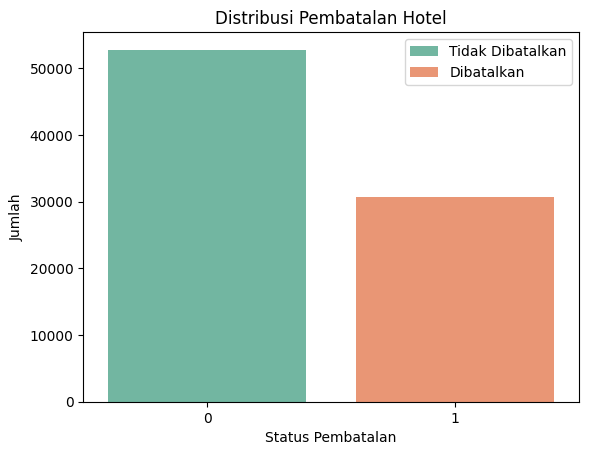

In [12]:
# Proporsi data yang dibatalkan dan tidak dibatalkan
print(df['is_canceled'].value_counts(normalize=True) * 100)

sns.countplot(x='is_canceled', data=df, palette='Set2')
plt.title('Distribusi Pembatalan Hotel')
plt.xlabel('Status Pembatalan')
plt.legend(['Tidak Dibatalkan', 'Dibatalkan'])
plt.ylabel('Jumlah')
plt.show()

Berdasarkan analisa tersebut:
1. Dataset memiliki **83,573 row** dengan **11 kolom**
2. Status pembatalan tidak seimbang (imbalance): **63.17% tidak batal vs 36.82% batal** = akurasi bisa menyesatkan. Sebaiknya kita menggunakan F1-score.
3. Hanya satu kolom yang memiliki missing value: `country` 
4. **Hampir 88%** adalah duplikat persis

## 5. Exploratory Data Analysis 

### Tingkat pembatalan per fitur kategorical 
Garis putus-putus menandai tingkat dasar keseluruhan (36,82%). Batang yang jauh dari garis ini memberikan sinyal.

/var/folders/r0/4lnkl5dn0yn1y1ttmn335r200000gn/T/ipykernel_33257/366082605.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.values, y=rate.index, palette='rocket')


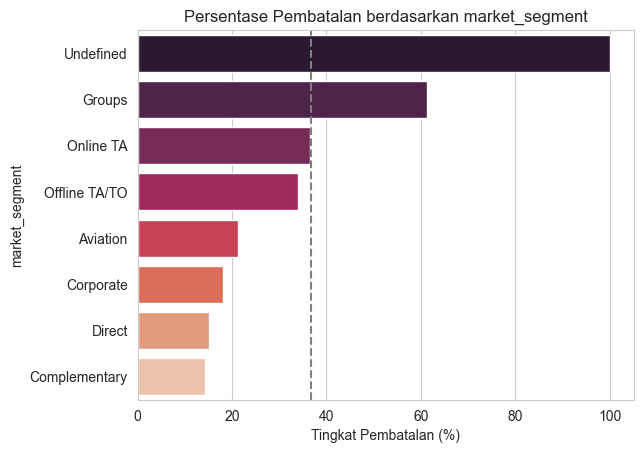

/var/folders/r0/4lnkl5dn0yn1y1ttmn335r200000gn/T/ipykernel_33257/366082605.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.values, y=rate.index, palette='rocket')


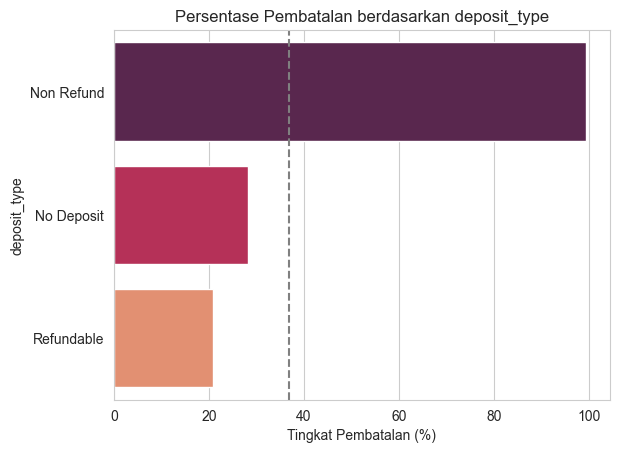

/var/folders/r0/4lnkl5dn0yn1y1ttmn335r200000gn/T/ipykernel_33257/366082605.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.values, y=rate.index, palette='rocket')


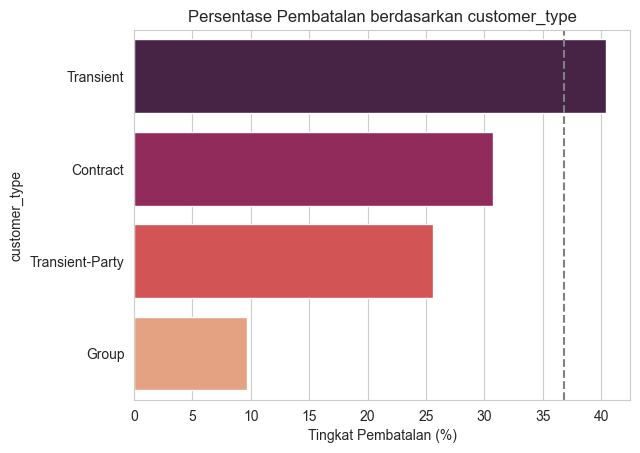

/var/folders/r0/4lnkl5dn0yn1y1ttmn335r200000gn/T/ipykernel_33257/366082605.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.values, y=rate.index, palette='rocket')


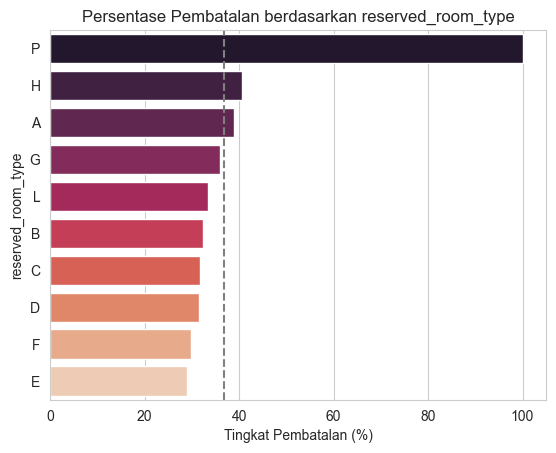

In [13]:
sns.set_style("whitegrid")

categorical_col = ["market_segment", "deposit_type", "customer_type", "reserved_room_type"]
for col in categorical_col:
    plt.axvline(x=36.82, color='gray', linestyle='--')
    rate = df.groupby(col)['is_canceled'].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.values, y=rate.index, palette='rocket')
    plt.title(f'Persentase Pembatalan berdasarkan {col}')
    plt.xlabel("Tingkat Pembatalan (%)")
    plt.show()

**Sinyal utama**
- **deposit_type = "Non-Refund"** memiliki hampir 100% rate dibatalkan. Ini sinyal terkuat sekaligus bagian data yang terdokumentasi dengan baik pada dataset ini.
- **market_segment = "Groups"** lebih sering dibatalkan (sekitar 60%) dibanding segment lainnya; mencerminkan komitmen
- **customer_type = "Transient"** (customer inap sementara) paling sering dibatalkan.

### Fitur numerik vs pembatalan

In [14]:
num_cols = ["previous_cancellations", "booking_changes", "days_in_waiting_list", "required_car_parking_spaces", "total_of_special_requests"]
mean_table = df.groupby("is_canceled")[num_cols].mean().round(3).transpose()
mean_table

is_canceled,0,1
previous_cancellations,0.016,0.208
booking_changes,0.293,0.097
days_in_waiting_list,1.572,3.631
required_car_parking_spaces,0.100,0.000
total_of_special_requests,0.716,0.327


In [15]:
corr = df[num_cols + ['is_canceled']].corr()["is_canceled"].drop("is_canceled")
print("Korelasi antara fitur numerik dan pembatalan:\n")
print(corr)

Korelasi antara fitur numerik dan pembatalan:

previous_cancellations         0.109598
booking_changes               -0.145746
days_in_waiting_list           0.056203
required_car_parking_spaces   -0.194807
total_of_special_requests     -0.235993
Name: is_canceled, dtype: float64


In [16]:
merged = pd.merge(mean_table, corr, on=mean_table.index)
merged.sort_values(by='is_canceled', ascending=True)

,key_0,0,1,is_canceled
4,total_of_special_requests,0.716,0.327,-0.235993
3,required_car_parking_spaces,0.100,0.000,-0.194807
1,booking_changes,0.293,0.097,-0.145746
2,days_in_waiting_list,1.572,3.631,0.056203
0,previous_cancellations,0.016,0.208,0.109598


**Sinyal utama**
- `total_of_special_requests` -> Semakin banyak permintaan khusus, semakin kecil kemungkinan batal (mean tidak batal 2x lebih besar daripada batal, korelasi = -0.23).
- `required_car_parking_spaces` -> Membutuhkan ruang parkir, hampir tidak pernah batal (pemesanan yang dibatalkan rata-rata 0,00 ruang, korelasi -0.195).
- `booking_changes` -> Tamu yang mengubah pesenannya akan jarang batal. Semakin  pergantian booking, kemungkinan pesanan kali ini tidak batal (mean tidak batal lebih besar, korelasi -0.146)
- `days_in_waiting_list` -> Jika hari menunggu lebih lama, maka risiko batal akan muncul (mean 1.5 hari tidak batal vs mean 3.6 hari batal, korelasi 0.05). Korelasinya sangat kecil, jadi sinyalnya paling lemah.
- `previous_cancellations` -> Jika customer yang pernah batal berkali-kali sebelumnya, kemungkinan risiko pembatalan akan lebih tinggi (mean 0.2, korelasi 0.11)

### Negara: Domestic vs International 

/var/folders/r0/4lnkl5dn0yn1y1ttmn335r200000gn/T/ipykernel_33257/2820584722.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.values, y=rate.index, palette='viridis')


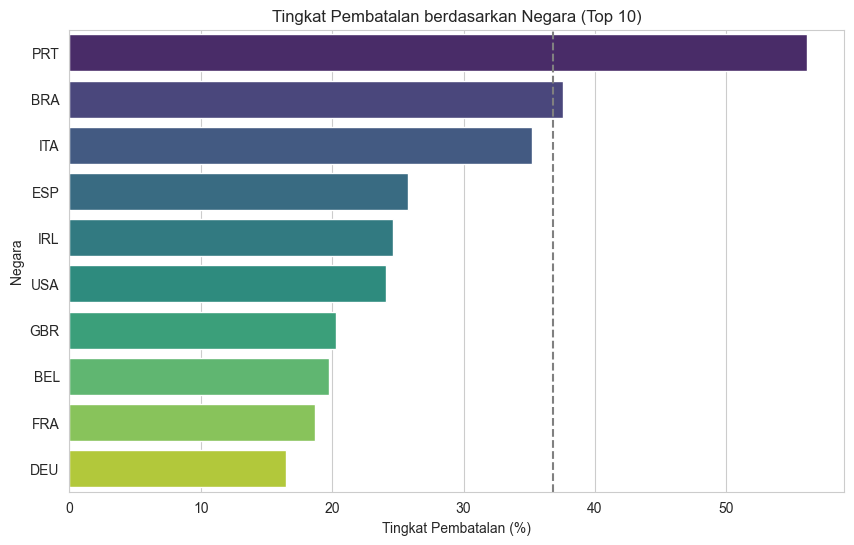

/var/folders/r0/4lnkl5dn0yn1y1ttmn335r200000gn/T/ipykernel_33257/2820584722.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette='viridis')


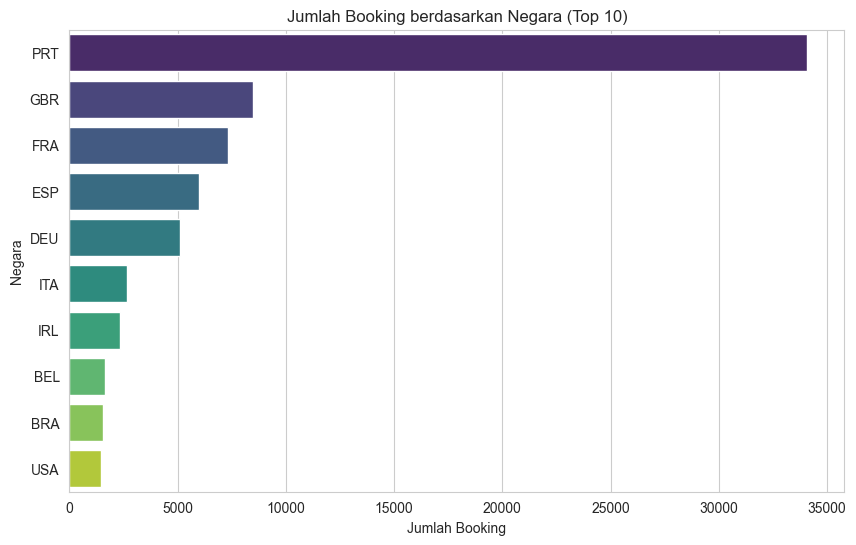

In [17]:
top = df["country"].value_counts().head(10)
rate = (df.groupby("country")["is_canceled"].mean().loc[top.index] * 100).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=rate.values, y=rate.index, palette='viridis')
plt.axvline(x=36.82, color='grey', linestyle='--', label='Rata-rata Pembatalan')
plt.title("Tingkat Pembatalan berdasarkan Negara (Top 10)")
plt.xlabel("Tingkat Pembatalan (%)")
plt.ylabel("Negara")
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=top.values, y=top.index, palette='viridis')
plt.title("Jumlah Booking berdasarkan Negara (Top 10)")
plt.xlabel("Jumlah Booking")
plt.ylabel("Negara")
plt.show()

**Portugal (PRT) yang juga merupakan pasar domestik** mendominasi volume dan memiliki tingkat pembatalan yang paling tinggi (56%). Dianjurkan memberikan flagging `is_domestic` dan mengelompokkan negara-negara langka untuk mengendalikan kardinalitas. 

## 6. Data Cleaning

In [18]:
df_cleaned = df.copy()

# Mengisi nilai yang hilang pada kolom 'country' dengan 'Unknown'
df_cleaned["country"] = df_cleaned["country"].fillna("Unknown")

# Pemeriksaan nilai negatif pada kolom numerik
negative = (df_cleaned[df_cleaned[num_cols] < 0]).count()
print(f"Jumlah nilai negatif sebelum pembersihan:\n{negative}")


Jumlah nilai negatif sebelum pembersihan:
country                        0
market_segment                 0
previous_cancellations         0
booking_changes                0
deposit_type                   0
days_in_waiting_list           0
customer_type                  0
reserved_room_type             0
required_car_parking_spaces    0
total_of_special_requests      0
is_canceled                    0
dtype: int64


Pembersihan dataset tidak rumit: kita hanya mengisi nilai hiland pada kolom `country` dengan `Unknown` dan memeriksa nilai negatif pada kolom numerik (ternyata tidak ada). 

Mengenai baris duplikat, butuh pertimbangan khusus. Kita akan bahas keputusannya setelah melihat dampak yang terjadi jika duplikat dihapus.

Tingkat pembatalan - data penuh: 36.83%
Tingkat pembatalan - data setelah dedup: 23.66%
Baris tersisa setelah dedup: 10,202 dari 83,573


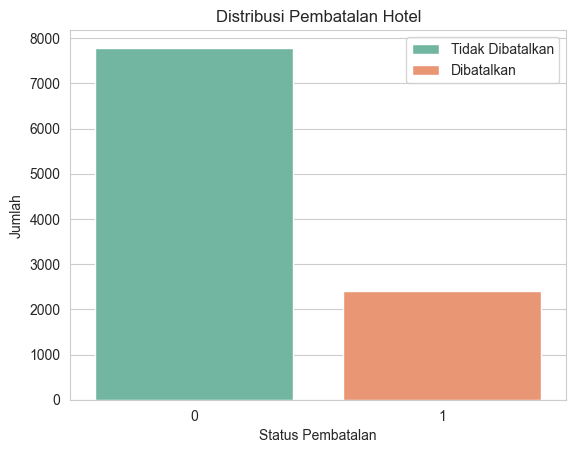

In [19]:
df_dropped = df_cleaned.drop_duplicates()

print(f"Tingkat pembatalan - data penuh: {df_cleaned['is_canceled'].mean() * 100:.2f}%")
print(f"Tingkat pembatalan - data setelah dedup: {df_dropped['is_canceled'].mean() * 100:.2f}%")
print(f"Baris tersisa setelah dedup: {len(df_dropped):,} dari {len(df_cleaned):,}")

sns.countplot(x='is_canceled', hue='is_canceled', data=df_dropped, palette='Set2')
plt.title('Distribusi Pembatalan Hotel')
plt.xlabel('Status Pembatalan')
plt.legend(['Tidak Dibatalkan', 'Dibatalkan'])
plt.ylabel('Jumlah')
plt.show()

**Keputusan final: baris duplikat dipertahankan.**

Hasil di atas menunjukkan dampak bila duplikat dihapus: Hampir 88% data dibuang dan tingkat pembatalan bergeser dari 36.8% menjadi 23.6%; baris identik menjadi pembeda pemesanan yang valid (tamu memesan 2x), bukan kesalahan input, karena kolom pembeda seperti tanggal dan harga tidak ada dalam dataset.

Risiko yang ada dalam dataset ini bukan duplikatnya, melainkan **kebocoran data**: baris duplikat bisa muncul di data latih dan uji sekaligus. Maka kita memutuskan untuk mempertahankan semua baris untuk melatih model, ukur besarnya kebocoran, dan dilaporkan metrik versi dedup sebagai batas bawah konservatif (Dilihat bagian Evaluasi Kebocoran Data)

## 7. Feature Engineering
Setelah ini, kita akan mengubah kolom hitungan raw menjadi signal-signal binary supaya model lebih mudah mengenali, menambahkan flag domestik, dan mengurangi kardinalitas kolom `country` dengan hanya menyimpan 20 negara teratas berdasarkan volume penjualan.

> Catatan: flag binary dan `is_domestic` bersifat row-wise sehingga aman. Pemilihan 20 negara teratas (`country_group`) memakai frekuensi pada seluruh data — berbasis frekuensi, **bukan** target, sehingga risiko kebocorannya kecil (penjelasan lengkap di bagian Preprocessing).

In [20]:
df = df_cleaned.copy()

df["is_domestic"] = (df["country"] == "PRT").astype(int)
df["is_repeated_canceller"] = (df["previous_cancellations"] > 0).astype(int)
df["has_booking_changes"] = (df["booking_changes"] > 0).astype(int)
df["was_in_waiting_list"] = (df["days_in_waiting_list"] > 0).astype(int)
df["requires_parking"] = (df["required_car_parking_spaces"] > 0).astype(int)
df["has_special_requests"] = (df["total_of_special_requests"] > 0).astype(int)

# Mengurangi kardinalitas "country"
top20 = df["country"].value_counts().head(20).index
df["country_group"] = df["country"].apply(lambda x: x if x in top20 else "Other")
df.drop(columns=["country"], inplace=True)

df.head()

,market_segment,previous_cancellations,booking_changes,deposit_type,days_in_waiting_list,customer_type,reserved_room_type,required_car_parking_spaces,total_of_special_requests,is_canceled,is_domestic,is_repeated_canceller,has_booking_changes,was_in_waiting_list,requires_parking,has_special_requests,country_group
0,Offline TA/TO,0,0,No Deposit,0,Transient-Party,A,0,0,0,0,0,0,0,0,0,IRL
1,Online TA,0,0,No Deposit,0,Transient,A,0,2,0,0,0,0,0,0,1,FRA
2,Online TA,0,1,No Deposit,0,Transient,A,0,2,0,1,0,1,0,0,1,PRT
3,Online TA,0,0,No Deposit,0,Transient,A,0,1,1,0,0,0,0,0,1,NLD
4,Online TA,0,2,No Deposit,0,Transient,A,0,2,0,1,0,1,0,0,1,PRT


## 8. Preprocessing
Kita memisahkan data lebih dulu, lalu membungkus scaler dan encoder dalam sebuah `Pipeline` agar keduanya hanya dilatih (`fit`) pada data latih di setiap fold cross-validation. Ini mencegah kebocoran statistik (mis. median dan daftar kategori) dari data uji. Pemisahan dilakukan secara stratified untuk mempertahankan tingkat pembatalan 36,8% di kedua subset.

> Tidak semua langkah dilakukan setelah split. Pengelompokan `country_group` (top-20) di Feature Engineering dihitung dari frekuensi seluruh data sebelum split. Karena hanya memakai frekuensi kemunculan dan tidak menyentuh target `is_canceled`, ini bukan kebocoran target dan risikonya rendah. Untuk pipeline produksi yang ketat, daftar top-20 sebaiknya ditetapkan dari data latih saja.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

categorical_cols = ["market_segment", "deposit_type", "customer_type", "reserved_room_type", "country_group"]
numerical_cols = ["previous_cancellations", "booking_changes", "days_in_waiting_list", "required_car_parking_spaces", "total_of_special_requests", "is_repeated_canceller", "has_booking_changes", "was_in_waiting_list", "requires_parking", "has_special_requests", "is_domestic"]

X = df[categorical_cols + numerical_cols]
y = df["is_canceled"]           # TARGET

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Tingkat pembatalan pada data latih: {y_train.mean() * 100:.2f}%")
print(f"Tingkat pembatalan pada data uji: {y_test.mean() * 100:.2f}%")

Tingkat pembatalan pada data latih: 36.83%
Tingkat pembatalan pada data uji: 36.83%


Pada data ini, imbalancenya termasuk sedang, bukan yang ekstrim. Ada dua cara untuk menanganinya: resampling/oversampling (membuat baris minoritas buatan agar jumlah seimbang) atau class weighting (menyuruh model menganggap kesalahan pada kelas minoritas lebih berharga, sehingga model lebih memperhatikannya).

Dalam kasus ini, kita memilih untuk menggunakan class weighting dengan metode `class_weight=balanced` karena alasan-alasan tersebut:
1. Data ini mayoritas baris duplikat, sehingga data buatan akan berisiko merusak prediksi model.
2. Data weighting mempertahankan distribusi data yang sebelumnya dan tidak menambah risiko kebocoran saat cross-validation, sehingga mengurangi halusinasi model.

In [22]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

- **`RobustScaler`** dipilih untuk kolom numerik karena beberapa kolom (seperti `days_in_waiting_list`, `previous_cancellations`) sangat *skewed* dan punya outlier
ekstrim. RobustScaler memakai median dan IQR, sehingga kebal outlier. StandardScaler dan MinMaxScaler tidak digunakan karena terseret nilai ekstrim. Scaling ini membuat baseline Logistic Regression adil dan tidak merugikan model pohon.
- **`OneHotEncoder`** dipakai karena kolom kategorik bersifat *nominal* (tanpa urutan),sehingga one-hot menghindari urutan palsu yang akan muncul dari label encoding.Argumen `handle_unknown='ignore'` membuat kategori baru saat prediksi tidak memicu error (di-encode sebagai seluruh-nol).


## 9. Modelling 
Sekarang, kita membandingkan 4 algoritma machine learning, dari yang bisa diintepretasi sampai yang kuat, semuanya dengan `class_weight="balanced"` untuk mengatasi data imbalance dan dievaluasi dengan cross-valudation stratified 5-fold pada metrik yang sama. Tujuan dari perbandingan ini adalah melihat apakah tambahan kompleksitas bisa memberikan performa terbaik.

| Model | Kenapa disertakan |
|---|---|
| **Logistic Regression** | Baseline transparan, koefisien (rasio odds) mudah dijelaskan. |
| **Decision Tree** | Menangkap interaksi non-linear (misal "Non-Refund" -> hampir pasti batal), interpretabel, bisa menjadi dasar menuju ensemble. |
| **Random Forest** | Pohon yang dibagging, tangguh, menangani fitur campuran, tahan overfitting. |
| **Hist Gradient Boosting** | Boosting sekuensial (gaya LightGBM), biasanya terbaik untuk data tabular.

3 dari 4 model ini tree-based karena metode pohon menangani interaksi non-linear dan campuran fitur numerik-kategorik dengan baik tanpa banyak asumsi distribusi, maka cocok dipakai untuk dataset ini. Namun, model seperti KNN dan SVM tidak disertakan karena kurang scalable pada baris lebih dari 60 ribu dan lebih sulit diinterpretasi.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "HistGradientBoosting": HistGradientBoostingClassifier(class_weight='balanced')
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["f1", "roc_auc", "average_precision"]

rows = []
for name, clf in models.items():
    pipeline = Pipeline([("prep", preprocessor), ("clf", clf)])
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({
        "Model": name,
        "F1 Score": scores["test_f1"].mean().round(4),
        "ROC_AUC": scores["test_roc_auc"].mean().round(4),
        "PR_AUC": scores["test_average_precision"].mean().round(4)
        })

cv_results = pd.DataFrame(rows).sort_values(by="F1 Score", ascending=False)
cv_results 

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
   

,Model,F1 Score,ROC_AUC,PR_AUC
3,HistGradientBoosting,0.7420,0.8934,0.8503
2,Random Forest,0.7384,0.8877,0.8448
1,Decision Tree,0.7369,0.8797,0.8233
0,Logistic Regression,0.7193,0.8700,0.8229


Setelah melakukan modelling, ternyata HistGradientBoosting (HGB) memiliki nilai yang paling tinggi dari antara empat model yang digunakan dengan F1-score 0.7413. Model ini akan digunakan untuk hyperparameter tuning di bagian selanjutnya, supaya performa model lebih baik.

### Hyperparameter Tuning 
Modelling sebelumnya masih belum menggunakan hyperparameter yang sesuai untuk prediksi, sehingga F1-score masih kurang optimal. Oleh karena itu, kita memutuskan untuk melakukan hyperparameter tuning supaya kita mendapat nilai F1-score yang lebih optimal. 

In [24]:
from sklearn.model_selection import GridSearchCV

tune_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", HistGradientBoostingClassifier(class_weight='balanced', random_state=42))
])

param_grid = {
    'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'clf__min_samples_leaf': [20, 50 ,100, 200],
    'clf__max_iter': [100, 200, 500, 1000],
    'clf__max_leaf_nodes': [15, 31, 63, 127]
}

search = GridSearchCV(tune_pipe, param_grid, scoring='f1', cv=cv, n_jobs=-1)
search.fit(X_train, y_train)

print(f"Parameter terbaik: {search.best_params_}")
print(f"F1 Score terbaik: {search.best_score_:.4f}")

final = search.best_estimator_

Parameter terbaik: {'clf__learning_rate': 0.1, 'clf__max_iter': 200, 'clf__max_leaf_nodes': 63, 'clf__min_samples_leaf': 50}
F1 Score terbaik: 0.7435


## 10. Model Evaluation and Metric Justification 
Kita akan mengambil model teratas berdasarkan F1 score cross validation, melatihnya pada seluruh data training, dan mengevaluasinya satu kali pada data testing.

In [25]:
best_name = cv_results.iloc[0]["Model"]
print(f"Model terbaik berdasarkan F1 Score: {best_name}")

Model terbaik berdasarkan F1 Score: HistGradientBoosting


                  precision    recall  f1-score   support

Tidak Dibatalkan      0.867     0.804     0.834     10559
      Dibatalkan      0.701     0.788     0.742      6156

        accuracy                          0.798     16715
       macro avg      0.784     0.796     0.788     16715
    weighted avg      0.806     0.798     0.800     16715

ROC AUC Score: 0.8937
Average Precision Score: 0.8524


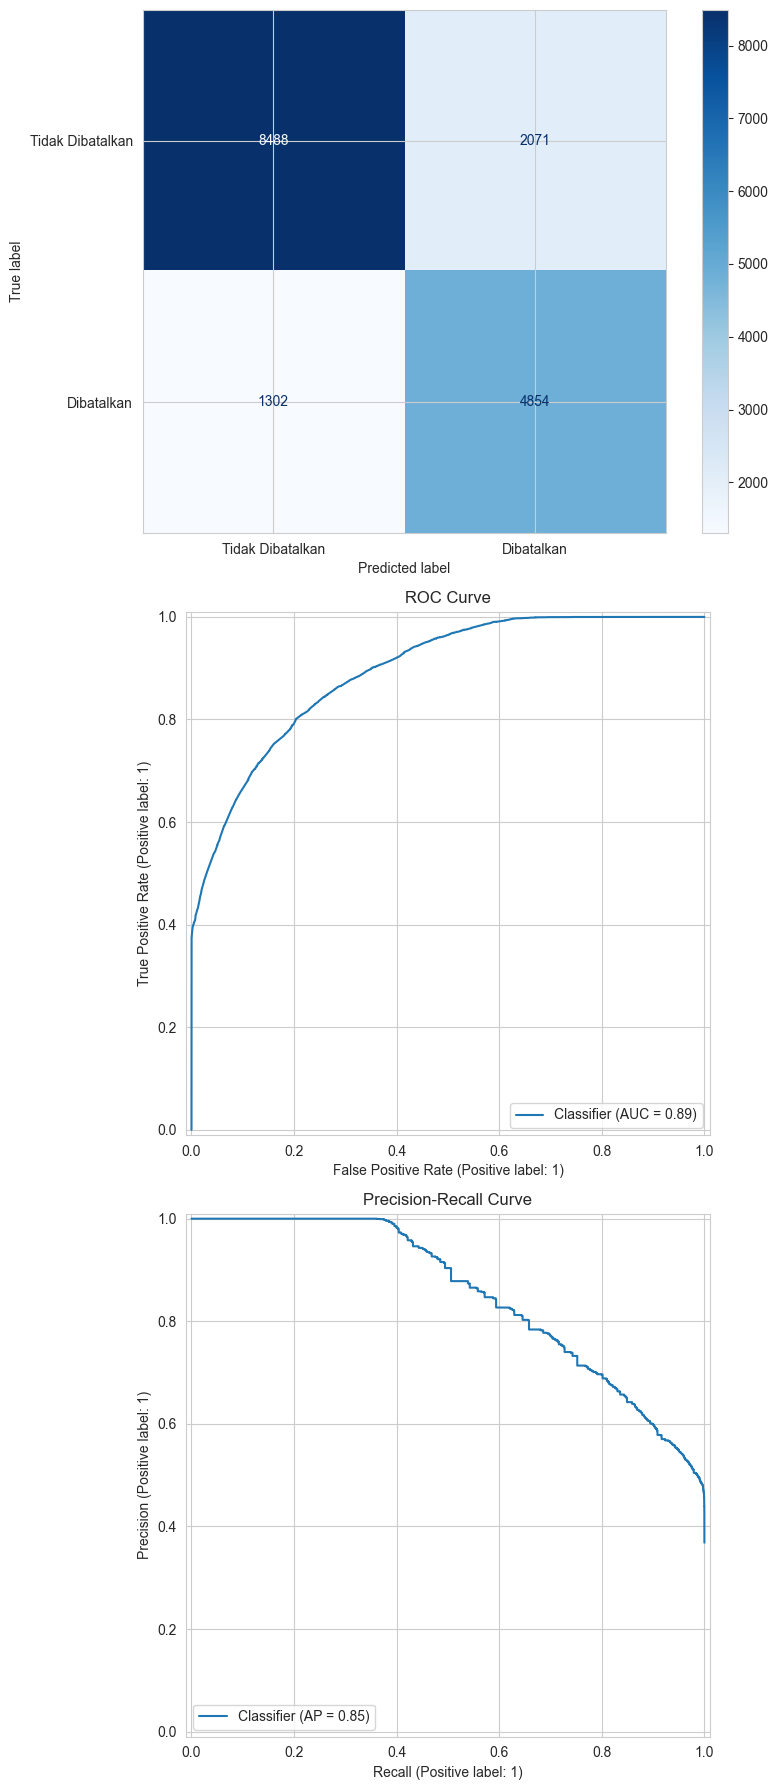

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, average_precision_score, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

proba = final.predict_proba(X_test)[:, 1]
pred = final.predict(X_test)

print(classification_report(y_test, pred, target_names = ["Tidak Dibatalkan", "Dibatalkan"], digits=3))
print(f"ROC AUC Score: {roc_auc_score(y_test, proba):.4f}")
print(f"Average Precision Score: {average_precision_score(y_test, proba):.4f}")

fig, ax = plt.subplots(3, 1, figsize=(8, 18))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), 
                       display_labels=["Tidak Dibatalkan", "Dibatalkan"]).plot(ax=ax[0], cmap='Blues')
RocCurveDisplay.from_predictions(y_test, proba, ax=ax[1])
ax[1].set_title("ROC Curve")
PrecisionRecallDisplay.from_predictions(y_test, proba, ax=ax[2])
ax[2].set_title("Precision-Recall Curve")
plt.tight_layout()

**Membaca hasil pada data uji (ambang default 0,5).** Fokus kita ada pada kelas **Dibatalkan**:
- **Recall 0,788**: model menangkap ~79% dari seluruh pembatalan nyata (4.854 tertangkap, 1.302 terlewat). Ini angka terpenting karena setiap pembatalan yang terlewat artinya kamar dibiarkan kosong.
- **Precision 0,701**: dari semua pesanan yang ditandai "akan batal", 70% memang batal. Sisanya (2.071) salah alarm.
- **F1 0,742**: rangkuman keseimbangan recall dan precision, yaitu metrik utama kita.

Recall yang lebih tinggi daripada precision justru kita inginkan: lebih baik sedikit salah alarm daripada melewatkan pembatalan yang merugikan.

**Metrik bebas ambang:** ROC-AUC **0,894** dan PR-AUC **0,852** menunjukkan kemampuan pemeringkatan risiko yang kuat, jauh di atas garis dasar acak. Accuracy (0,798) sengaja tidak dijadikan acuan karena menyesatkan pada data yang imbalance.

> Catatan: angka ini dihitung pada split naif yang masih mengandung duplikat sehingga sedikit optimis.

### Overfitting vs. Underfitting Diagnostic 

In [27]:
# Diagnostik overfitting/underfitting: skor di data latih vs data uji
from sklearn.metrics import f1_score, roc_auc_score

train_pred  = final.predict(X_train)
train_proba = final.predict_proba(X_train)[:, 1]

print(f"F1  - latih: {f1_score(y_train, train_pred):.4f} | uji: {f1_score(y_test, pred):.4f}")
print(f"F1 cross-validation (5-fold): {cv_results.iloc[0]['F1 Score']:.4f}")

F1  - latih: 0.7481 | uji: 0.7421
F1 cross-validation (5-fold): 0.7420


Berdasarkan test F1-score, dapat dilihat bahwa model ini tidak underfitting dan tidak overfitting dikarenakan F1 cross-validation (0,7413) dan F1 data uji (0,7421) memiliki nilai yang hampir sama. Ditambah lagi, F1 latih (0,7481) memiliki nilai yang tidak jauh dari F1 uji, menandakan model berhasil memprediksi data tanpa harus menghafal (jika jauh melebihi F1 uji sudah termasuk overfitting).

### Evaluasi Bebas Kebocoran

Karena hampir 88% adalah baris duplikat, split acak biasa membuat sebagian baris uji memiliki duplikat di data latih, sehingga skor cenderung optimis. Di sini kita akan mengevaluasi ulang tanpa kebocoran, di mana data di-deduplikasi dulu, baru dibagi, sehingga tidak ada baris yang sama muncul di latih sekaligus uji. F1 score di bagian ini adalah batas bawah yang lebih jujur (tidak nyontek)

In [28]:
from sklearn.base import clone
df_unique = df.drop_duplicates()
Xu = df_unique.drop(columns=["is_canceled"])
yu = df_unique["is_canceled"]
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(Xu, yu, test_size=0.2, random_state=42, stratify=yu)

clean = clone(final)
clean.fit(X_train_u, y_train_u)
pred_u = clean.predict(X_test_u)
proba_u = clean.predict_proba(X_test_u)[:, 1]

# ✏️ [EDIT] perbaikan NameError: yte_u->y_test_u, pu->pred_u, pru->proba_u
print(f"F1  - split naif (bocor): {f1_score(y_test, pred):.4f} | bebas-kebocoran: {f1_score(y_test_u, pred_u):.4f}")
print(f"AUC - split naif (bocor): {roc_auc_score(y_test, proba):.4f} | bebas-kebocoran: {roc_auc_score(y_test_u, proba_u):.4f}")
print(f"Tingkat pembatalan -> original: {df['is_canceled'].mean()*100:.2f}% | dedup: {yu.mean()*100:.2f}%")

F1  - split naif (bocor): 0.7421 | bebas-kebocoran: 0.5553
AUC - split naif (bocor): 0.8937 | bebas-kebocoran: 0.8185
Tingkat pembatalan -> original: 36.83% | dedup: 22.95%


Setelah diuji dengan data tanpa duplikasi, ternyata performa model turun (F1 0.74 -> 0.56 dan AUC 0.89 -> 0.82). Ini artinya F1-score awal terbantu sedikit dari kebocoran akibat baris duplikat, dan 0.56 adalah perkiraan batas bawah yang lebih jujur. Kemampuan model sesungguhnya berada di kedua rentang metrik (0.56 - 0.74).

Tingkat pembatalan juga turun dari 36,83% menjadi 22,95% setelah didedup. Itulah alasan mengapa dedup tidak dipakai untuk melatih model karena menghapus duplikat akan mengubah proporsi batal dan mengubah problem statement kita modelkan.

## 11. Analisa Ambang Batas 
Ambang batas default 0,5 bersifat sembarang. Kita memberikan biaya dolar untuk setiap jenis kesalahan dan memilih ambang batas yang meminimalkan total biaya, sehingga model selaras langsung dengan kebutuhan bisnis.

> Ambang dipilih dari `proba` pada data uji lalu dilaporkan pada data uji yang sama demi kesederhanaan, sehingga angka pada ambang optimal cenderung sedikit optimis. Pada penerapan nyata, ambang sebaiknya dipilih pada data validasi terpisah (atau via cross-validation) lalu dikonfirmasi sekali pada data uji.

Threshold optimal berdasarkan biaya: 0.2650
Threshold optimal berdasarkan F1 Score: 0.4850


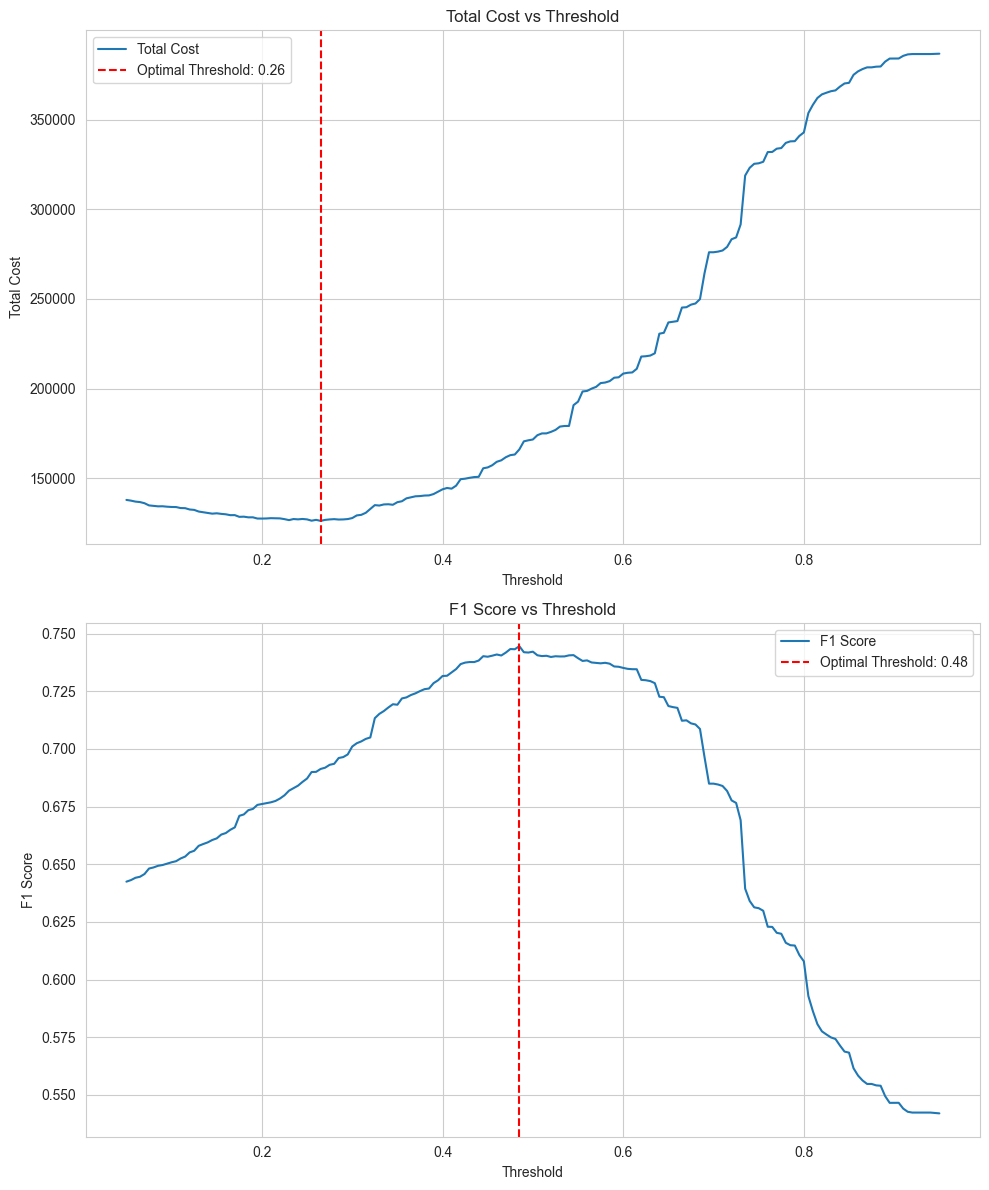

In [29]:
COST_FN = 100   # Asumsi biaya untuk False Negative (batal terlewat)
COST_FP = 20    # Asumsi biaya untuk False Positive (salah batal)

threshold = np.linspace(0.05, 0.95, 181)
total_cost = []
f1_scores = []
for t in threshold:
    p = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, p).ravel()
    total_cost.append((COST_FN * fn) + (COST_FP * fp))
    f1_scores.append(f1_score(y_test, p))

best_threshold = threshold[np.argmin(total_cost)]
best_f1_threshold = threshold[np.argmax(f1_scores)]
print(f"Threshold optimal berdasarkan biaya: {best_threshold:.4f}") 
print(f"Threshold optimal berdasarkan F1 Score: {best_f1_threshold:.4f}")

fig, ax = plt.subplots(2, 1, figsize=(10, 12))
ax[0].plot(threshold, total_cost, label='Total Cost')
ax[0].axvline(x =best_threshold, color='red', linestyle='--', label=f'Optimal Threshold: {best_threshold:.2f}')
ax[0].set_title("Total Cost vs Threshold")
ax[0].set_xlabel("Threshold")
ax[0].set_ylabel("Total Cost")
ax[1].plot(threshold, f1_scores, label='F1 Score')
ax[1].axvline(x=best_f1_threshold, color='red', linestyle='--', label=f'Optimal Threshold: {best_f1_threshold:.2f}')
ax[1].set_title("F1 Score vs Threshold")
ax[1].set_xlabel("Threshold")
ax[1].set_ylabel("F1 Score")
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

In [30]:
pred_t = (proba >= best_threshold).astype(int)
print(classification_report(y_test, pred_t, target_names = ["Tidak Dibatalkan", "Dibatalkan"], digits=3))

pred_f1 = (proba >= best_f1_threshold).astype(int)
print(classification_report(y_test, pred_f1, target_names = ["Tidak Dibatalkan", "Dibatalkan"], digits=3))

                  precision    recall  f1-score   support

Tidak Dibatalkan      0.955     0.526     0.679     10559
      Dibatalkan      0.541     0.957     0.691      6156

        accuracy                          0.685     16715
       macro avg      0.748     0.742     0.685     16715
    weighted avg      0.802     0.685     0.683     16715

                  precision    recall  f1-score   support

Tidak Dibatalkan      0.872     0.796     0.833     10559
      Dibatalkan      0.696     0.800     0.745      6156

        accuracy                          0.798     16715
       macro avg      0.784     0.798     0.789     16715
    weighted avg      0.807     0.798     0.800     16715



Dari hasil di atas, ada dua threshold yang telah dianalisa: cost threshold dan optimal threshold. Cost threshold berada di 0.265 sedangkan optimal score berada di 0.485. Walaupun threshold 0.485 terlihat sangat bagus karena F1-score yang tinggi (0.745), kita memilih untuk menggunakan threshold 0.265 karena:
1. Recall tinggi 95.7%: model menangkap hampir 96% pembatalan asli. Jadi hampir tidak ada kamar kosong yang tidak diantisipasi.
2. Precision turun jadi 54.1%: setengah dari dataset mendapatkan sinyal keliru (batal tapi ternyata datang). Masih bisa ditoleransi karena biaya FP kecil.
3. Accuracy turun jadi 68.5%: Tujuan utamanya adalah mencari error yang bisa merugikan sekali. Jadi ini dibiarkan saja.

Dengan threshold ini, kita bisa menurunkan kerugian kehilangan kamar.

## 12. Model Interpretation

Fitur manakah yang sebenarnya menggerakkan prediksi? Dengan **permutation importance**, kita bisa mengukur seberapa besar F1 score turun ketika setiap fitur diacak 

/var/folders/r0/4lnkl5dn0yn1y1ttmn335r200000gn/T/ipykernel_33257/3794633596.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette='mako')


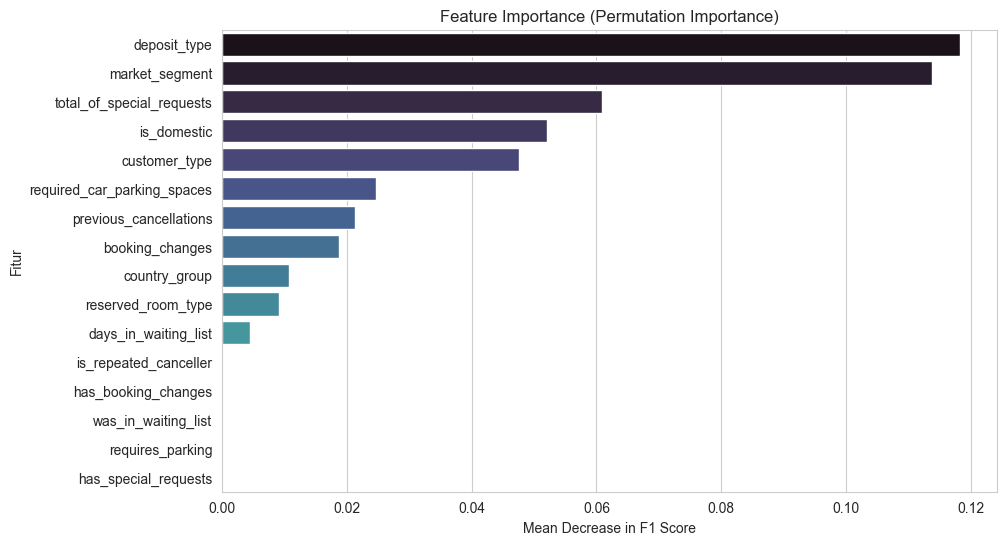

deposit_type                   0.118327
market_segment                 0.113745
total_of_special_requests      0.060916
is_domestic                    0.052129
customer_type                  0.047617
required_car_parking_spaces    0.024702
previous_cancellations         0.021228
booking_changes                0.018677
country_group                  0.010677
reserved_room_type             0.009054
dtype: float64

In [31]:
from sklearn.inspection import permutation_importance

r = permutation_importance(final, X_test, y_test, n_repeats=5, random_state=42, scoring="f1", n_jobs=-1)
imp = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=imp.values, y=imp.index, palette='mako')
plt.title("Feature Importance (Permutation Importance)")
plt.xlabel("Mean Decrease in F1 Score")
plt.ylabel("Fitur")
plt.show()

imp.sort_values(ascending=False).head(10)

Sesuai dengan dugaan EDA, `deposit_type` dan `market_segment` terbukti menjadi fitur yang paling berpengaruh dalam prediksi model, diikuti `total_of_special_requests`, `is_domestic`, dan `customer_type`.

## 13. Model Limitations

**1. Fitur hanya terbatas 11 kolom:** Menurut kami, model ini bisa lebih bagus jika ada fitur berupa waktu, jumlah malam menginap, atau harga kamar.

**2. Bias ke populasi dan waktu:** Data diambil dari sebuah hotel di Portugal, periode tidak diketahui. Belum tentu berlaku untuk wilayah lain, kelas hotel berbeda, atau musim pasar yang berbeda.

**3. Sinyal `deposit_type = Non-Refund` perlu diwaspadai** Fitur ini menjadi pendorong terkuat dalam prediksi kali ini, tetapi pada data hotel ini kategori Non-Refund hampir selalu berakhir batal. Kepentingan fitur ini juga belum tentu bertahan jika diberi data baru. Jadi, jangan langsung menjadi dasar kebijakan tanpa validasi.

**Kapan dipercaya atau tidak:**
- **Dipercaya jika:** untuk pemesanan mirip data latih: segmen umum, negara bervolume besar, dan pola standar.
- **Kurang dipercaya jika:** untuk negara bervolume kecil, segmen pasar baru, atau periode dengan kondisi yang sangat berbeda dari data latih.

## 14. Manfaat Bisnis
Lantas, apa kegunaan nyata model ini dan bagaimana model tersebut menciptakan nilai ke depan? Inti idenya sederhana: model mengubah setiap pemesanan menjadi skor risiko pembatalan (0-100%), sehingga keputusan yang dulu mengandalkan firsat kini dapat diarahkan oleh data.

### Untuk siapa dan kapan dipakai
| Untuk siapa? | Cara memakai skor model | Frekuensi |
|---|---|---|
| **Revenue Manager** | Mengkalibrasi tingkat *overbooking* berdasarkan total risiko portofolio pemesanan | Harian / mingguan |
| **Front-Office / Reservasi** | Memprioritaskan **konfirmasi ulang** pada pemesanan berisiko tinggi | Harian |
| **Tim Kebijakan/Komersial** | Menerapkan **deposit atau syarat non-refundable secara selektif**, bukan menyamaratakan | Saat menyusun kebijakan |
| **Manajer Operasional** | Menyesuaikan **penjadwalan staf & pengadaan** dari prakiraan okupansi yang lebih akurat | Mingguan |

### Manfaat Utama
1. **Memulihkan pendapatan**: Pembatalan yang terdeteksi lebih awal dapat diantisipasi (dijual ulang, overbooking terukur, atau konfirmasi ulang), mengubah kamar yang tadinya menganggur menjadi pendapatan.
2. **Penargetan yang lebih efisien**: Alih-alih membebani semua tamu dengan deposit (yang berisiko menurunkan konversi), hotel cukup menargetkan segmen berisiko untuk menjaga pengalaman tamu yang berkomitmen.
3. **Prediksi lebih akurat**: Estimasi kamar dipakai berisih (setelah memperhitungkan risiko pembatalan) memperbaiki perencanaan harga, staf, dan logistik.
4. **Keputusan berbasis bukti**: Faktor pendorong yang transparan (jenis deposit, kanal, permintaan khusus, riwayat pembatalan) membuat kebijakan dapat dijelaskan dan diaudit.

### Estimasi Dampak Finansial (Perumpamaan)
Cell di bawah ini menerjemahkan kinerja model menjadi proyeksi nilai tahunan dengan menskalakan hasil pada data uji ke estimasi volume pemesanan per tahun. Karena periode pengambilan data tidak diketahui, rentang waktu data diperlakukan sebagai asumsi eksplisit (`data_span_years`) yang bisa diganti apabila informasinya tersedia.

Angka di bawah ini bukan angka yang pasti, melainkan sebagai perumpaan cara model ini menjadi nilai bisnis.
1. **FN = $100/booking** Kamar yang harusnya bisa dijual jadi nganggur. Biaya loss $100 didapat dari asumsi biaya hotel yang ada di Portugal di Agoda.com (Range dari $35 - $270, tergantung bintang hotel).
2. **FP = $20/booking** Tamu yang niat datang malah ditandai berisiko batal. Biaya loss $20 didapat dari asumsi biaya operational tambahan (seperti biaya staff dan waktu konfirmasi ulang).

**Cara menghitung nilai model:**
Model berhasil menebak sebagian besar pembatalan (True Positives) dan untuk setiap tebakan benar, hotel bisa menjual ulang kamar, sehingga menyelamatkan uang yang tadinya hilang (sebesar biaya FN per pemesanan). Tapi model juga bisa salah alarm, menandai tamu yang sebenarnya datang (False Positive). Tiap salah alarm ada biayanya, sebesar biaya False Positive per pemesanan

Untuk menghitung asumsi keuntungan bersih per booking (uang yang dapat dari model deteksi pembatalan) = (TP * biaya FN) - (FP * biaya FP) / jumlah data uji 
(Biaya FP dikurangi karena itu kerugian, bukan keuntungan)

In [32]:
pred_fin = (proba >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred_fin).ravel()
n_test = len(y_test)
net_per_booking = ((tp * COST_FN) - (fp * COST_FP)) / n_test
booking_total = len(df)
data_span_years = 2
bookings_per_year = booking_total / data_span_years
net_annual_cost = net_per_booking * bookings_per_year
print("="*64)
print("PROYEKSI DAMPAK FINANSIAL (PERUMPAMAAN)")
print("="*64)
print(f"Asumsi biaya                  : FN = ${COST_FN} (kamar nganggur), FP = ${COST_FP} (gangguan)")
print(f"Asumsi rentang biaya          : {data_span_years} tahun")
print(f"Untung bersih per booking     : ${net_per_booking:,.2f}")
print(f"Estimasi booking/tahun        : {bookings_per_year:,.0f}")
print(f"Estimasi nilai pulih/tahun    : ${net_annual_cost:,.2f}")

PROYEKSI DAMPAK FINANSIAL (PERUMPAMAAN)
Asumsi biaya                  : FN = $100 (kamar nganggur), FP = $20 (gangguan)
Asumsi rentang biaya          : 2 tahun
Untung bersih per booking     : $29.28
Estimasi booking/tahun        : 41,786
Estimasi nilai pulih/tahun    : $1,223,370.72


## 15. Kesimpulan dan Rekomendasi

In [33]:
from sklearn.metrics import precision_score, recall_score

print("="*64)
print("RINGKASAN ANALISIS")
print("="*64)
print(f"Model terbaik            : {best_name}")
print(f"Metrik utama             : F1 Score pada kelas 'dibatalkan'")
print("-"*64)
print("F1 pada beberapa threshold:")
print(f"Threshold default (0.5)  : {f1_score(y_test, pred):.4f} dengan precision={precision_score(y_test, pred):.4f} dan recall={recall_score(y_test, pred):.4f}")
print(f"Threshold optimal (biaya): {f1_score(y_test, pred_t):.4f} pada threshold {best_threshold:.2f} dengan precision={precision_score(y_test, pred_t):.4f} dan recall={recall_score(y_test, pred_t):.4f}")
print(f"Threshold optimal (F1)   : {f1_score(y_test, (proba >= best_f1_threshold).astype(int)):.4f} pada threshold {best_f1_threshold:.2f} dengan precision={precision_score(y_test, (proba >= best_f1_threshold).astype(int)):.4f} dan recall={recall_score(y_test, (proba >= best_f1_threshold).astype(int)):.4f}")
print("-"*64)
print("Metrik pendukung (bebas ambang)")
print(f"ROC-AUC                  : {roc_auc_score(y_test, proba):.4f}")
print(f"PR-AUC                   : {average_precision_score(y_test, proba):.4f}")
print("="*64)

RINGKASAN ANALISIS
Model terbaik            : HistGradientBoosting
Metrik utama             : F1 Score pada kelas 'dibatalkan'
----------------------------------------------------------------
F1 pada beberapa threshold:
Threshold default (0.5)  : 0.7421 dengan precision=0.7009 dan recall=0.7885
Threshold optimal (biaya): 0.6913 pada threshold 0.26 dengan precision=0.5409 dan recall=0.9574
Threshold optimal (F1)   : 0.7445 pada threshold 0.48 dengan precision=0.6962 dan recall=0.8000
----------------------------------------------------------------
Metrik pendukung (bebas ambang)
ROC-AUC                  : 0.8937
PR-AUC                   : 0.8524


### Kesimpulan
Dengan F1 pada kelas 'Dibatalkan' sebagai titik tumpu, model **HistGradientBoosting** terpilih sebagai yang terbaik pada cross validation 5-fold. F1 dipakai karena menyeimbangkan kemampuan menangkap pembatalan (recall) dengan menjaga sinyal keliru tetap rendah (precision), dan diukur pada ambang operasi yang benar-benar dipakai, bukan sembarang angka abstrak.

Model menyediakan dua titik operasi untuk dua tujuan:
1. Pada ambang optimal biaya (0.26) ia memaksimalkan recall (95%) untuk menekan kerugian pendapatan dari pembatalan yang terlewat
2. Pada ambang optimal F1 (0.48), ia mencapai keseimbangan precision-recall yang terbaik (F1 tertinggi)

PR-AUC dan ROC-AUC dilaporkan sebagai metrik pendukung yang bebas ambang batas.

### Rekomendasi
1. Gunakan skor sebagai pemeringkatan risiko untuk mewajibkan deposit secara selektif pada pemesanan berisiko tinggi, mengkalibrasi cadangan overbooking, dan membuat konfirmasi ulang
2. Beroperasilah pada ambang batas berbasis biaya, disetel ulang dengan angka $ dari tim keuangan, bukan default 0,5
3. Perlakuan sinyal Non-Refund dengan hati-hati dan validasi ulang pada data langsung

### Next Step
Kita akan melatih ulang dengan data terkini + lokal, menambahkan fitur lebih kaya, memantau drift, menguji coba pada satu segmen sebelum peluncuran penuh, meminjau ulang biaya bersama tim keuangan untuk ambang batas yang benar-benar sensitif biaya.

## 16. Penyimpanan Model
Kita menyimpan seluruh pipeline (preprocessing + model) beserta ambang bantas operasinya, sehingga artefak tersimpan dapat menilai pemesanan mentah secara end-to-end

In [34]:
import pickle 

artifact = {
    "pipeline": final, 
    "threshold": float(best_threshold),
    "model_name": best_name,
    "features": {"categorical": categorical_cols, "numerical": numerical_cols}
}  

with open("model_final_pipeline.pkl", "wb") as f:
    pickle.dump(artifact, f)
print("Saved!")

Saved!
